# Regresión Logística — Clasificación de Calidad de Vino Tinto

En este ejercicio se implementa **regresión logística** desde cero y se aplica al dataset
**Wine Quality (Red)** para resolver un problema de **clasificación binaria**:

Etiqueta___________Significado

**Alta calidad** — puntuación de experto ≥ 6

**Baja calidad** — puntuación de experto < 6

El dataset contiene **1 599 muestras** y **11 características fisicoquímicas**.

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot
from scipy import optimize

%matplotlib inline

## 1 · Carga y exploración del dataset

El CSV usa `;` como separador. La columna `quality` (valores 3-8) se transforma a binario:
`1` si calidad ≥ 6, `0` en caso contrario.

In [2]:
# Cargar el dataset
data = pd.read_csv('/content/winequality-red.csv', sep=';')

# Crear la etiqueta binaria
data['quality'] = (data['quality'] >= 6).astype(int)

print("Primeras 10 filas del dataset:")
print(data.head(10).to_string())
print(f"\nForma del dataset: {data.shape}")
print(f"\nDistribución de clases:")
counts = data['quality'].value_counts()
print(f"   Alta calidad (1): {counts.get(1, 0)} muestras  ({counts.get(1,0)/len(data)*100}%)")
print(f"   Baja calidad (0): {counts.get(0, 0)} muestras  ({counts.get(0,0)/len(data)*100}%)")

Primeras 10 filas del dataset:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  alcohol  quality
0            7.4              0.70         0.00             1.9      0.076                 11.0                  34.0   0.9978  3.51       0.56      9.4        0
1            7.8              0.88         0.00             2.6      0.098                 25.0                  67.0   0.9968  3.20       0.68      9.8        0
2            7.8              0.76         0.04             2.3      0.092                 15.0                  54.0   0.9970  3.26       0.65      9.8        0
3           11.2              0.28         0.56             1.9      0.075                 17.0                  60.0   0.9980  3.16       0.58      9.8        1
4            7.4              0.70         0.00             1.9      0.076                 11.0                  34.0   0.9978  3.51       0.56      9.4       

In [3]:
# Separar características (X) y etiquetas (y)
feature_names = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
                  'chlorides', 'free sulfur dioxide', 'total sulfur dioxide',
                  'density', 'pH', 'sulphates', 'alcohol']

X = data[feature_names].values
y = data['quality'].values

print(f"Forma de X: {X.shape}  →  {X.shape[0]} muestras, {X.shape[1]} características")
print(f"Forma de y: {y.shape}")
print(f"\nPrimeras 5 filas de X (sin normalizar):")
print(np.round(X[:5], 3))
print(f"\nPrimeras 5 etiquetas (y):")
print(y[:5])

Forma de X: (1599, 11)  →  1599 muestras, 11 características
Forma de y: (1599,)

Primeras 5 filas de X (sin normalizar):
[[7.40e+00 7.00e-01 0.00e+00 1.90e+00 7.60e-02 1.10e+01 3.40e+01 9.98e-01
  3.51e+00 5.60e-01 9.40e+00]
 [7.80e+00 8.80e-01 0.00e+00 2.60e+00 9.80e-02 2.50e+01 6.70e+01 9.97e-01
  3.20e+00 6.80e-01 9.80e+00]
 [7.80e+00 7.60e-01 4.00e-02 2.30e+00 9.20e-02 1.50e+01 5.40e+01 9.97e-01
  3.26e+00 6.50e-01 9.80e+00]
 [1.12e+01 2.80e-01 5.60e-01 1.90e+00 7.50e-02 1.70e+01 6.00e+01 9.98e-01
  3.16e+00 5.80e-01 9.80e+00]
 [7.40e+00 7.00e-01 0.00e+00 1.90e+00 7.60e-02 1.10e+01 3.40e+01 9.98e-01
  3.51e+00 5.60e-01 9.40e+00]]

Primeras 5 etiquetas (y):
[0 0 0 1 0]


## 2 · Visualización de los datos

Para una gráfica 2D se seleccionan las dos características más informativas:
**alcohol** (eje X) y **acidez volátil** (eje Y).

Los vinos de **alta calidad** suelen tener más alcohol y menos acidez volátil.

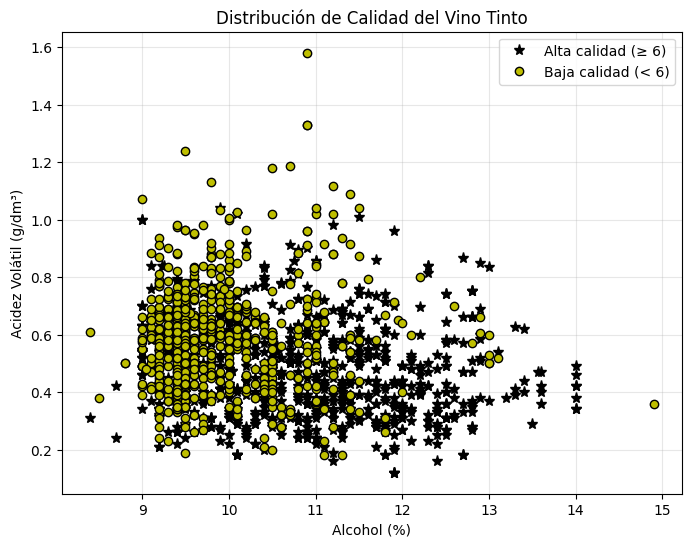

Visualización generada


In [4]:
def plotData(X, y, ix=10, iy=1, xlabel='Alcohol (%)', ylabel='Acidez Volátil (g/dm³)'):
    fig = pyplot.figure(figsize=(8, 6))
    pos = y == 1
    neg = y == 0
    pyplot.plot(X[pos, ix], X[pos, iy], 'k*', lw=2, ms=8,  label='Alta calidad (≥ 6)')
    pyplot.plot(X[neg, ix], X[neg, iy], 'ko', mfc='y', ms=6, mec='k', mew=1, label='Baja calidad (< 6)')
    pyplot.xlabel(xlabel)
    pyplot.ylabel(ylabel)
    pyplot.title('Distribución de Calidad del Vino Tinto')
    pyplot.legend()
    pyplot.grid(True, alpha=0.3)

plotData(X, y)
pyplot.show()
print("Visualización generada");

## 3 · Normalización de características

Con 11 características de escalas muy distintas (p. ej. pH ≈ 3.5 vs SO₂ total ≈ 100)
es **imprescindible normalizar** para que el descenso por el gradiente converja correctamente.

$$x_j^{(i)} \leftarrow \frac{x_j^{(i)} - \mu_j}{\sigma_j}$$

In [5]:
def normalizeFeatures(X):
    mu    = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

X_norm, mu, sigma = normalizeFeatures(X)

print("Estadísticas de normalización:")
print(f"{'Característica':<30} {'Media':>10} {'Desv. Est.':>12}")
for name, m_val, s_val in zip(feature_names, mu, sigma):
    print(f"  {name:<28} {m_val:>10.4f} {s_val:>12.4f}")

Estadísticas de normalización:
Característica                      Media   Desv. Est.
  fixed acidity                    8.3196       1.7406
  volatile acidity                 0.5278       0.1790
  citric acid                      0.2710       0.1947
  residual sugar                   2.5388       1.4095
  chlorides                        0.0875       0.0471
  free sulfur dioxide             15.8749      10.4569
  total sulfur dioxide            46.4678      32.8850
  density                          0.9967       0.0019
  pH                               3.3111       0.1543
  sulphates                        0.6581       0.1695
  alcohol                         10.4230       1.0653


## 4 · Función Sigmoide

La hipótesis de la regresión logística se define como:

$$h_\theta(x) = g(\theta^T x), \quad g(z) = \frac{1}{1 + e^{-z}}$$

In [6]:
def sigmoid(z):
    z = np.array(z)
    return 1.0 / (1.0 + np.exp(-z))

# Prueba de la función
test_vals = [-1000, -2, -1, 0, 1, 2, 1000]
results   = sigmoid(test_vals)
print("Prueba de la función sigmoide:")
for z_v, g_v in zip(test_vals, results):
    print(f"  sigmoid({z_v:6}) = {g_v:.6f}")
print(f"\n sigmoid(0) = {sigmoid(0):.1f}  (esperado exactamente 0.5)")

Prueba de la función sigmoide:
  sigmoid( -1000) = 0.000000
  sigmoid(    -2) = 0.119203
  sigmoid(    -1) = 0.268941
  sigmoid(     0) = 0.500000
  sigmoid(     1) = 0.731059
  sigmoid(     2) = 0.880797
  sigmoid(  1000) = 1.000000

 sigmoid(0) = 0.5  (esperado exactamente 0.5)


/tmp/ipykernel_4646/3654474248.py:3: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-z))


## 5 · Preparación de la matriz X

Se agrega una columna de unos al inicio de X para incluir el término de intercepción θ₀.

In [7]:
m, n = X_norm.shape
X_b  = np.concatenate([np.ones((m, 1)), X_norm], axis=1)  # (1599 x 12)

print(f"Forma de X (normalizada, con intercepción): {X_b.shape}")
print(f"  → {m} muestras, {n} características + 1 bias = {n+1} parámetros θ")

Forma de X (normalizada, con intercepción): (1599, 12)
  → 1599 muestras, 11 características + 1 bias = 12 parámetros θ


## 6 · Función de Costo y Gradiente

$$J(\theta) = -\frac{1}{m}\sum_{i=1}^{m}\left[y^{(i)}\log h_\theta(x^{(i)}) + (1-y^{(i)})\log(1-h_\theta(x^{(i)}))\right]$$

$$\frac{\partial J}{\partial \theta_j} = \frac{1}{m}\sum_{i=1}^{m}\left(h_\theta(x^{(i)}) - y^{(i)}\right)x_j^{(i)}$$

In [8]:
def costFunction(theta, X, y):
    m    = y.size
    h    = sigmoid(X.dot(theta))
    J    = -(1/m) * (y.dot(np.log(h)) + (1 - y).dot(np.log(1 - h)))
    grad = (1/m) * (h - y).dot(X)
    return J, grad

def calcularCosto(theta, X, y):
    m = y.size
    h = sigmoid(X.dot(theta))
    return -(1/m) * (y.dot(np.log(h)) + (1 - y).dot(np.log(1 - h)))


#pruebas
theta_cero = np.zeros(n + 1)
J0, grad0  = costFunction(theta_cero, X_b, y)
print(f"[Prueba 1]  θ = zeros")
print(f"  Costo  J  = {J0:.4f}  (esperado ≈ 0.6931 = ln 2)")
print(f"  Gradiente (primeros 5): {np.round(grad0[:5], 6)}")

rng = np.random.default_rng(42)
theta_test = rng.uniform(-0.1, 0.1, n + 1)
J_test, grad_test = costFunction(theta_test, X_b, y)
print(f"\n[Prueba 2]  θ aleatorio pequeño")
print(f"  Costo  J  = {J_test:.4f}")
print(f"  Gradiente (primeros 5): {np.round(grad_test[:5], 6)}")
print("\nFunción de costo verificada.")

[Prueba 1]  θ = zeros
  Costo  J  = 0.6931  (esperado ≈ 0.6931 = ln 2)
  Gradiente (primeros 5): [-0.034709 -0.047432  0.160333 -0.079373  0.001078]

[Prueba 2]  θ aleatorio pequeño
  Costo  J  = 0.6968
  Gradiente (primeros 5): [-0.021178 -0.065206  0.172195 -0.085025 -0.016511]

Función de costo verificada.


## 7 · Descenso por el Gradiente

Se implementa el algoritmo estándar de descenso por el gradiente y se muestra
la curva de convergencia del costo.

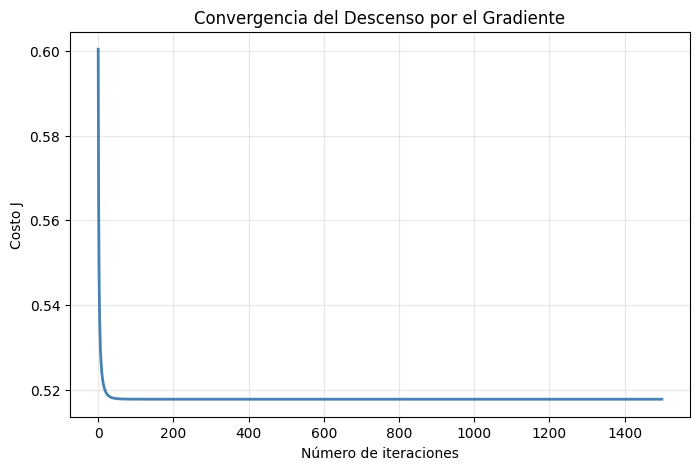

Costo inicial : 0.6004
Costo final   : 0.5177

Theta (θ) calculado por descenso por el gradiente:
  θ0  (bias                     ) = +0.240268
  θ1  (fixed acidity            ) = +0.236681
  θ2  (volatile acidity         ) = -0.587435
  θ3  (citric acid              ) = -0.248167
  θ4  (residual sugar           ) = +0.077981
  θ5  (chlorides                ) = -0.184237
  θ6  (free sulfur dioxide      ) = +0.232356
  θ7  (total sulfur dioxide     ) = -0.539115
  θ8  (density                  ) = -0.096096
  θ9  (pH                       ) = -0.058742
  θ10 (sulphates                ) = +0.473642
  θ11 (alcohol                  ) = +0.923455


In [9]:
def descensoGradiente(theta, X, y, alpha, num_iters):
    m         = y.shape[0]
    theta     = theta.copy()
    J_history = []
    for _ in range(num_iters):
        h     = sigmoid(X.dot(theta))
        theta = theta - (alpha / m) * (h - y).dot(X)
        J_history.append(calcularCosto(theta, X, y))
    return theta, J_history

# Hiperparámetros
alpha     = 1.0
num_iters = 1500
theta_init = np.zeros(n + 1)

theta_gd, J_history = descensoGradiente(theta_init, X_b, y, alpha, num_iters)

# Gráfica de convergencia
pyplot.figure(figsize=(8, 5))
pyplot.plot(np.arange(len(J_history)), J_history, lw=2, color='steelblue')
pyplot.xlabel('Número de iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Convergencia del Descenso por el Gradiente')
pyplot.grid(True, alpha=0.3)
pyplot.show()

print(f"Costo inicial : {J_history[0]:.4f}")
print(f"Costo final   : {J_history[-1]:.4f}")
print(f"\nTheta (θ) calculado por descenso por el gradiente:")
for i, (name, th) in enumerate(zip(['bias'] + feature_names, theta_gd)):
    print(f"  θ{i:<2} ({name:<25}) = {th:+.6f}")

## 8 · Optimización con `scipy.optimize.minimize` (método TNC)

Se usa el optimizador TNC (Truncated Newton Conjugate-Gradient) para hallar
el θ óptimo de manera más eficiente que el descenso puro por el gradiente.

In [12]:
options = {'maxiter': 2000}

res = optimize.minimize(
    costFunction,
    theta_init,
    args=(X_b, y),
    jac=True,
    method='TNC',
    options=options
)

theta_opt  = res.x
cost_final = res.fun

print(f"Costo final con optimize.minimize: {cost_final:.4f}")
print(f"Convergencia exitosa: {res.success}")
print(f"Mensaje: {res.message}")
print(f"\nTheta (θ) optimizado:")
for i, (name, th) in enumerate(zip(['bias'] + feature_names, theta_opt)):
    print(f"  θ{i:<2} ({name:<25}) = {th:+.6f}")
print("\nOptimización completada.")

Costo final con optimize.minimize: 0.5177
Convergencia exitosa: True
Mensaje: Converged (|f_n-f_(n-1)| ~= 0)

Theta (θ) optimizado:
  θ0  (bias                     ) = +0.240267
  θ1  (fixed acidity            ) = +0.236703
  θ2  (volatile acidity         ) = -0.587431
  θ3  (citric acid              ) = -0.248162
  θ4  (residual sugar           ) = +0.077991
  θ5  (chlorides                ) = -0.184239
  θ6  (free sulfur dioxide      ) = +0.232360
  θ7  (total sulfur dioxide     ) = -0.539116
  θ8  (density                  ) = -0.096116
  θ9  (pH                       ) = -0.058728
  θ10 (sulphates                ) = +0.473645
  θ11 (alcohol                  ) = +0.923442

Optimización completada.


/tmp/ipykernel_4646/3395474148.py:3: OptimizeWarning: Unknown solver options: maxiter
  res = optimize.minimize(


## 9 · Función de Predicción

Umbral en 0.5: si `sigmoid(θᵀx) ≥ 0.5` → clase 1 (alta calidad).

In [13]:
def predict(theta, X):
    return np.round(sigmoid(X.dot(theta))).astype(int)

# Predicción sobre el conjunto de entrenamiento
p_train = predict(theta_opt, X_b)
acc     = np.mean(p_train == y) * 100

print(f"Precisión de entrenamiento: {acc}%")
print(f"Aciertos: {int(np.sum(p_train == y))} / {m}")

Precisión de entrenamiento: 74.42151344590368%
Aciertos: 1190 / 1599


## 10 · Pruebas Finales — Verificación del Modelo

Se predicen dos vinos con perfiles fisicoquímicos distintos para confirmar
que el modelo generaliza correctamente.

In [14]:
def predecir_vino(muestra_raw, theta, mu, sigma, feature_names):
    arr       = np.array(muestra_raw).reshape(1, -1)
    arr_norm  = (arr - mu) / sigma
    arr_b     = np.concatenate([np.ones((1, 1)), arr_norm], axis=1)
    prob      = sigmoid(arr_b.dot(theta))[0]
    etiqueta  = int(np.round(prob))
    calidad   = 'Alta calidad (≥ 6)' if etiqueta == 1 else 'Baja calidad (< 6)'
    return prob, etiqueta, calidad

print("  PRUEBA 1 — Vino con perfil de ALTA CALIDAD esperada")
# Perfil: alcohol alto, acidez volátil baja, buen nivel de sulfatos
muestra1 = [7.5, 0.40, 0.36, 2.1, 0.071, 17.0, 66.0, 0.9978, 3.35, 0.82, 11.5]
prob1, label1, calidad1 = predecir_vino(muestra1, theta_opt, mu, sigma, feature_names)
print(f"  Características:")
for name, val in zip(feature_names, muestra1):
    print(f"    {name:<30}: {val}")
print(f"\n  ➤ Probabilidad de alta calidad : {prob1} ({prob1*100}%)")
print(f"  ➤ Predicción del modelo          : {calidad1}")

print()
print("  PRUEBA 2 — Vino con perfil de BAJA CALIDAD esperada")
# Perfil: alcohol bajo, acidez volátil alta (típicamente vino de menor calidad)
muestra2 = [7.4, 0.74, 0.00, 1.9, 0.076, 11.0, 34.0, 0.9978, 3.51, 0.56, 9.4]
prob2, label2, calidad2 = predecir_vino(muestra2, theta_opt, mu, sigma, feature_names)
print(f"  Características:")
for name, val in zip(feature_names, muestra2):
    print(f"    {name:<30}: {val}")
print(f"\n  ➤ Probabilidad de alta calidad : {prob2} ({prob2*100}%)")
print(f"  ➤ Predicción del modelo          : {calidad2}")

print()
print("  RESUMEN FINAL DEL ENTRENAMIENTO")
print(f"  Dataset          : Wine Quality Red (1 599 muestras, 11 características)")
print(f"  Modelo           : Regresión Logística (implementación propia + TNC)")
print(f"  Costo final J(θ) : {cost_final}")
print(f"  Precisión (train): {acc}%")
print("  Estado            :Entrenamiento completado con éxito")

  PRUEBA 1 — Vino con perfil de ALTA CALIDAD esperada
  Características:
    fixed acidity                 : 7.5
    volatile acidity              : 0.4
    citric acid                   : 0.36
    residual sugar                : 2.1
    chlorides                     : 0.071
    free sulfur dioxide           : 17.0
    total sulfur dioxide          : 66.0
    density                       : 0.9978
    pH                            : 3.35
    sulphates                     : 0.82
    alcohol                       : 11.5

  ➤ Probabilidad de alta calidad : 0.8171736838912733 (81.71736838912733%)
  ➤ Predicción del modelo          : Alta calidad (≥ 6)

  PRUEBA 2 — Vino con perfil de BAJA CALIDAD esperada
  Características:
    fixed acidity                 : 7.4
    volatile acidity              : 0.74
    citric acid                   : 0.0
    residual sugar                : 1.9
    chlorides                     : 0.076
    free sulfur dioxide           : 11.0
    total sulfur dioxide  